<h1 align="center">Communities and Crime Dataset</h1>
<h3 align="center">Branislav Trstenský</h3>

> Dataset: UCI Machine Learning Repository (ID: 183)\
> Redmond, M. (2002). Communities and Crime.\
> <https://doi.org/10.24432/C53W3X>

Violent crime is a symptom of many systemic factors. Using the combination of socio-economic data and the crime rate data, a machine learning model will be created to predict crime rate based on external influence. Based on the features determined to be most influential, action could be taken to mitigate these factors and thus possibly lower the resulting crime rate.

**Task 5:** The dataset has a very large number of features and many of them are correlated. To ameliorate this, a dimensionality reduction will be applied. Performance with and without this step will be compared across all models.

**Task 2:** This project will attempt to use regression with the help of many types of models. Their performance, explainability and reproducibility will be compared and conclusions will be made based on their learned parameters.

# Exploratory Data Analysis

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/data.csv", na_values="?")

metadata_cols = ["state", "county", "community", "communityname", "fold"]
response_variable = "ViolentCrimesPerPop"

X = df.drop(metadata_cols + [response_variable], axis=1)
y = df[[response_variable]]

print(f"Original shape: X={X.shape}, y={y.shape}")
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Original shape: X=(1994, 122), y=(1994, 1)
Features: 122, Samples: 1994


### Predicted Variable

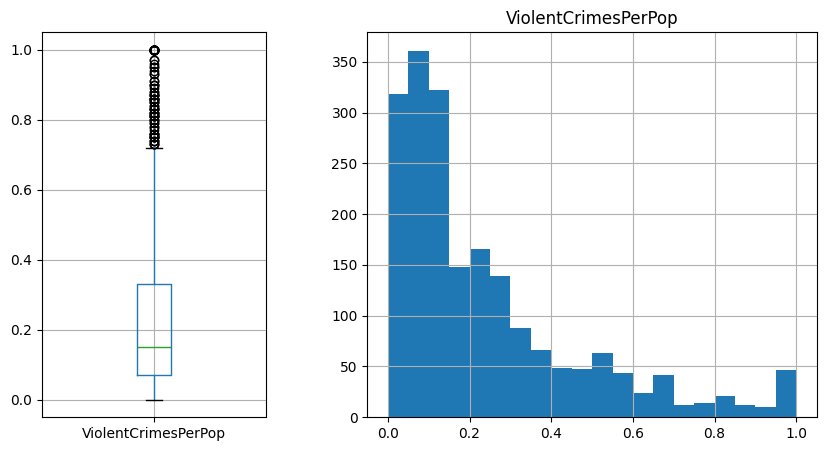

In [3]:
fig, [ax, ay] = plt.subplots(1, 2, figsize=(10, 5),width_ratios=(1/3,2/3 ))
y.boxplot(ax=ax)
y.hist(bins=20, ax=ay)
pass

The crime rate is highly skewed left. 

$\textcolor{cyan}{\text{TODO: Write about not much can be done to get normal dist but at least fix the skew}}$

array([-3.60243095])

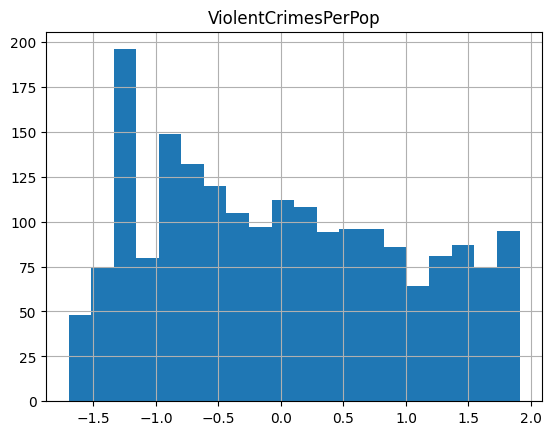

In [3]:
from sklearn.preprocessing import PowerTransformer


y = pd.DataFrame((_ := PowerTransformer()).fit_transform(y), columns=y.columns)
y.hist(bins=20)
_.lambdas_

### Missing values

The dataset also contains law enforcement data, but it is from a separate survey that lacks data for most of the samples. This features will be dropped. There is also the matter of `OtherPerCap` which is missing one value. This one samples can just be discarded.

In [4]:
(_ := X.isnull().sum())[_ > 0]

OtherPerCap                1
LemasSwornFT            1675
LemasSwFTPerPop         1675
LemasSwFTFieldOps       1675
LemasSwFTFieldPerPop    1675
LemasTotalReq           1675
LemasTotReqPerPop       1675
PolicReqPerOffic        1675
PolicPerPop             1675
RacialMatchCommPol      1675
PctPolicWhite           1675
PctPolicBlack           1675
PctPolicHisp            1675
PctPolicAsian           1675
PctPolicMinor           1675
OfficAssgnDrugUnits     1675
NumKindsDrugsSeiz       1675
PolicAveOTWorked        1675
PolicCars               1675
PolicOperBudg           1675
LemasPctPolicOnPatr     1675
LemasGangUnitDeploy     1675
PolicBudgPerPop         1675
dtype: int64

In [5]:
X = X.drop((_ := X.isnull().sum())[_ > 1].index, axis=1)
X = X.drop(_ := X[X.OtherPerCap.isnull()].index[0])
y = y.drop(_)
X.shape

(1993, 100)

### Scaling

In this dataset all values were already scaled to a `0..1` range by its creators. 

In [7]:
X.agg(["min", "max"]).T

,min,max
population,0.0,1.0
householdsize,0.0,1.0
racepctblack,0.0,1.0
racePctWhite,0.0,1.0
racePctAsian,0.0,1.0
...,...,...
PctSameState85,0.0,1.0
LandArea,0.0,1.0
PopDens,0.0,1.0
PctUsePubTrans,0.0,1.0


For PCA, Z-score normalization is preferred. This will simultaneously ensure the data is centered and ensure a constant standard deviation.

In [6]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X.agg(["min", "max"])

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn
min,-0.453982,-2.830909,-0.70895,-3.093315,-0.736180,-0.619813,-2.733392,-3.440754,-2.019827,-2.361615,...,-0.226992,-0.933214,-2.980354,-2.950498,-3.124276,-3.286877,-0.59606,-1.146911,-0.706166,-0.391560
max,7.426050,3.277600,3.24664,1.009312,4.051885,3.681776,3.710101,3.525552,3.986253,3.220267,...,9.733284,3.394137,1.915298,2.564787,1.864013,1.758445,8.53989,3.777352,3.659862,3.769575


# Dimensionality reduction

### Principal Component Analysis (PCA)

PCA will transform the data into a number of components. The goal is to set the number to capture the most amount of variance, while still getting a useful reduction in features. Because this dataset is a 

In [9]:
from sklearn.decomposition import PCA

pca = PCA(random_state=4221)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

/tmp/ipykernel_391064/1202517344.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


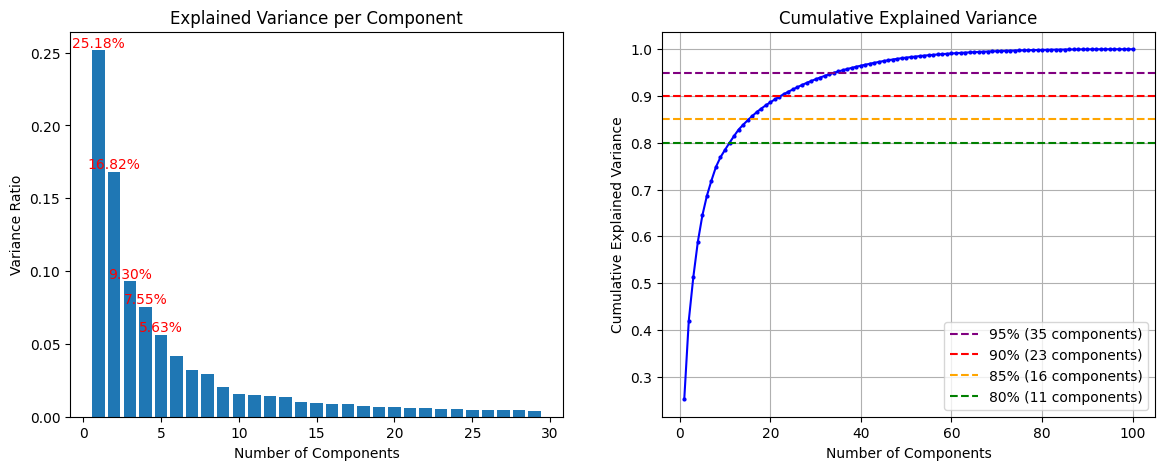

In [ ]:
ax: "plt.Axes"
ay: "plt.Axes"
fig, [ax, ay] = plt.subplots(1, 2, figsize=(14, 5))

ax.set_title("Explained Variance per Component")
bars = ax.bar(range(1, 30), pca.explained_variance_ratio_[:29])
ax.set_xlabel("Number of Components")
ax.set_ylabel("Variance Ratio")
ax.bar_label(bars, labels=[f"{v*100:.2f}%" for v in pca.explained_variance_ratio_[:5]], fmt="", color="r")

ay.set_title("Cumulative Explained Variance")
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
ay.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-o', markersize=2)
ay.set_xlabel('Number of Components')
ay.set_ylabel('Cumulative Explained Variance')
ay.axhline(y=0.95, color='purple', linestyle='--', label=f'95% ({np.argmax(cumulative_variance >= 0.95) + 1} components)')
ay.axhline(y=0.90, color='r', linestyle='--', label=f'90% ({np.argmax(cumulative_variance >= 0.90) + 1} components)')
ay.axhline(y=0.85, color='orange', linestyle='--', label=f'85% ({np.argmax(cumulative_variance >= 0.85) + 1} components)')
ay.axhline(y=0.80, color='g', linestyle='--', label=f'80% ({np.argmax(cumulative_variance >= 0.80) + 1} components)')
ay.legend()
ay.grid()

In [11]:
print(cumulative_variance[20])

0.8927097561611681


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, random_state=4221)
pca.fit(X)
X_pca = pca.transform(X)

### Partial Least Squares (PLC)

While PCA only looks at the variance within features, PLC also considers their correlation with the predicted variable.

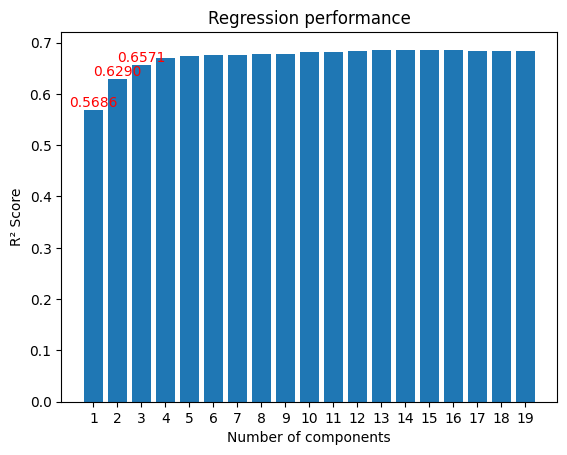

In [13]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score

plot_x = []
plot_y = []

for i in range(1, 20):
    pls = PLSRegression(n_components=i, scale=False)
    score = cross_val_score(pls, X, y).mean()
    plot_x.append(i)
    plot_y.append(score)

fig, ax = plt.subplots(1, 1)

ax.set_title("Regression performance")
ax.set_xlabel("Number of components")
ax.set_ylabel("R² Score")
bars = ax.bar(plot_x, plot_y)
ax.bar_label(bars, labels=[f"{v:.4f}" for v in plot_y[:3]], fmt="", color="r")
ax.set_xticks(plot_x)
pass

The number of components before diminishing returns show is `3`.

In [8]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=3, scale=False)
pls.fit(X, y)
X_pls = pls.transform(X)

### LDA

While not being designed for continuous output value, LDA can be used by discretizing the predicted variable.

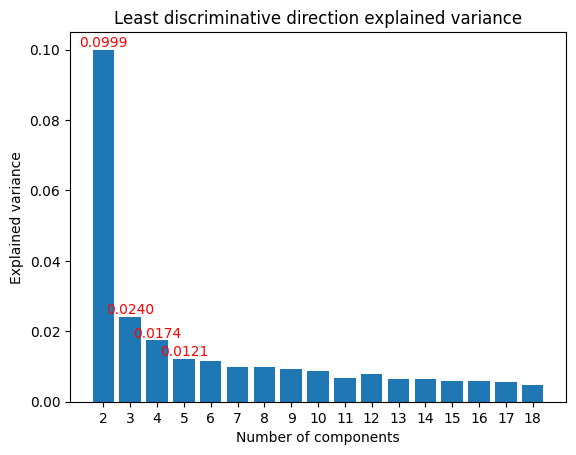

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

plot_x = []
plot_y = []

for i in range(3, 20):
    y_binned = pd.qcut(y.iloc[:,0], q=i, labels=False, duplicates='drop')
    actual_classes = len(np.unique(y_binned))

    if actual_classes != i:
        print(f"Skipping {i} ({actual_classes})")
        continue

    max_lda_components = actual_classes - 1
    lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
    lda.fit_transform(X, y_binned)
    plot_x.append(max_lda_components)
    plot_y.append(lda.explained_variance_ratio_[-1])

fig, ax = plt.subplots(1, 1)

ax.set_title("Least discriminative direction explained variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Explained variance")
bars = ax.bar(plot_x, plot_y)
ax.bar_label(bars, labels=[f"{v:.4f}" for v in plot_y[:4]], fmt="", color="r")
ax.set_xticks(plot_x)
pass

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

y_binned = pd.qcut(y.iloc[:,0], q=4, labels=False, duplicates='drop')
actual_classes = len(np.unique(y_binned))

max_lda_components = actual_classes - 1
lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_lda = lda.fit_transform(X, y_binned)

# Model comparison

First, we'll try out all models with both original data and the dimensionally reduced datasets. The defaults setting will be kept for now, they will be refined where applicable based on the initial results.

In [33]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

models = [
    # ===== Parametric =====

    # Partial least squares regression should handle the large amount of features. It reduces
    # the predictors by also using the response value, so it may have better results that just
    # learning on features reduced without supervision.
    PLSRegression(),
    # Elastic net combines L1 and L2 regularisation from lasso and ridge methods while
    # reportedly being more accurate than both. ElasticNetCV should find the correct values of
    # `alpha` and `l1_ratio`.
    ElasticNetCV(n_jobs=-1),
    # I expect linear regression to have problems, considering the large amount of features with
    # high collinearity, but using the reduced feature space, it may produce good outputs while
    # having high explainability.
    LinearRegression(),


    # ===== Nonparametric =====
    
    # Despite being nonparametric, a decision tree is simple to explain.
    DecisionTreeRegressor(),
    # If a single decision tree is insufficient, a random forest may be required. Random forest
    # also provides a validation set from OOB samples, but in the interest of having universal
    # testing code we're not going to use it.
    RandomForestRegressor(oob_score=False, n_jobs=-1),
    # Another attempt to improve decision tree performance (by default gradient boosting uses decision trees).
    GradientBoostingRegressor(),
    # kNN will be probably hopeless with the full dataset, but with the dimensionality reduced
    # datasets it could work. kNN regression is good when there are clusters of similar data,
    # but no global trend, which may be useful for this dataset which models human behaviour
    # across a large area.
    KNeighborsRegressor()
]

In [34]:
from typing import Any

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

def test_model[T: Any](name: str, model: T, x: Any = X, y = y) -> tuple[T, float]:
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=9138)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    print(f"{name} : R²: {r2:.4f}")

    return model, r2

In [35]:
def test_performance(
    datasets = [
        ("All", X),
        ("PCA", X_pca),
        ("PLS", X_pls),
        ("LDA", X_lda),
    ],
    models=models
):

    performance = pd.DataFrame(columns=[v for v, _ in datasets], index=[v.__class__.__name__ for v in models])

    for dataset_name, X_dataset in datasets:
        print(f"-- {dataset_name}")
        for model in models:
            model_name = model.__class__.__name__
            _, r2 = test_model(model_name, model, X_dataset)
            performance.at[model_name, dataset_name] = r2

    return performance


In [37]:
performance = test_performance()
performance

-- All
PLSRegression : R²: 0.6191
ElasticNetCV : R²: 0.6655
LinearRegression : R²: 0.6735
DecisionTreeRegressor : R²: 0.2947
RandomForestRegressor : R²: 0.6951
GradientBoostingRegressor : R²: 0.7041
KNeighborsRegressor : R²: 0.6201
-- PCA
PLSRegression : R²: 0.6570
ElasticNetCV : R²: 0.6580
LinearRegression : R²: 0.6572
DecisionTreeRegressor : R²: 0.2142
RandomForestRegressor : R²: 0.6715
GradientBoostingRegressor : R²: 0.6839
KNeighborsRegressor : R²: 0.6159
-- PLS
PLSRegression : R²: 0.6486
ElasticNetCV : R²: 0.6486
LinearRegression : R²: 0.6486
DecisionTreeRegressor : R²: 0.4388
RandomForestRegressor : R²: 0.6612
GradientBoostingRegressor : R²: 0.6799
KNeighborsRegressor : R²: 0.6561
-- LDA
PLSRegression : R²: 0.6979
ElasticNetCV : R²: 0.6977
LinearRegression : R²: 0.6979
DecisionTreeRegressor : R²: 0.4709
RandomForestRegressor : R²: 0.6995
GradientBoostingRegressor : R²: 0.7024
KNeighborsRegressor : R²: 0.6677


,All,PCA,PLS,LDA
PLSRegression,0.619097,0.657009,0.648615,0.697932
ElasticNetCV,0.66546,0.657971,0.648606,0.697723
LinearRegression,0.673549,0.657176,0.64862,0.697932
DecisionTreeRegressor,0.294694,0.214244,0.438801,0.470911
RandomForestRegressor,0.695065,0.671519,0.661227,0.699517
GradientBoostingRegressor,0.704146,0.683873,0.679864,0.702364
KNeighborsRegressor,0.620058,0.615851,0.656102,0.667748


<Axes: ylabel='R² Score'>

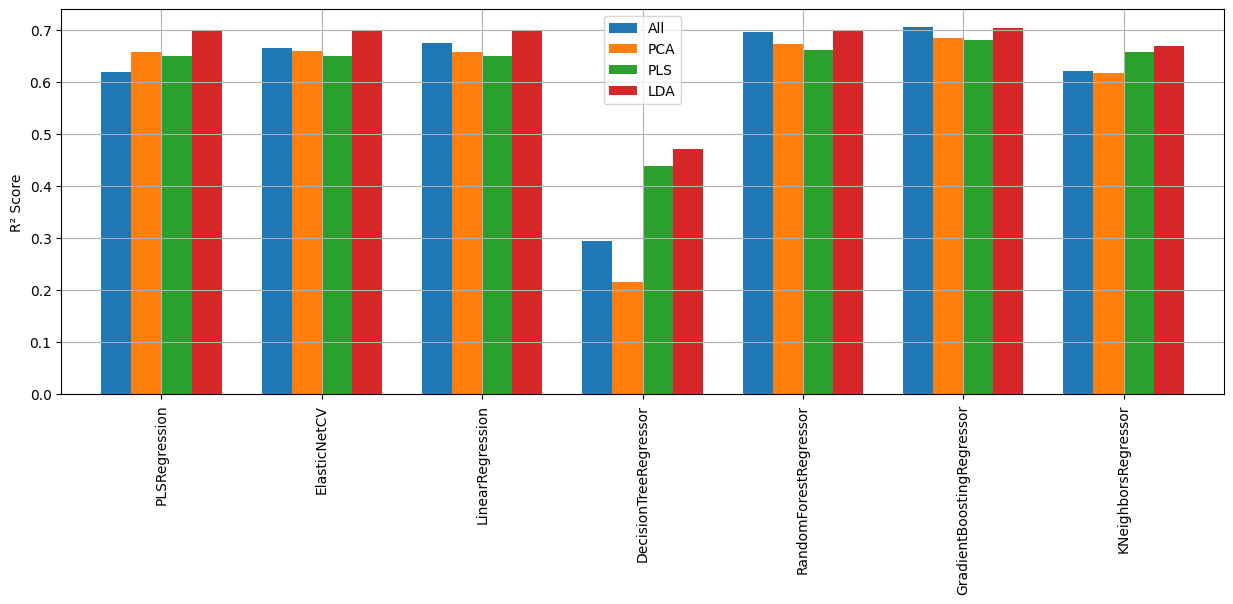

In [40]:
performance.plot.bar(figsize=(15, 5), width=0.75, grid=True, ylabel="R² Score")

$\textcolor{cyan}{\text{TODO: Add conclusion about how reduction methods impact performance}}$

### Performance of RandomForestRegressor